<a href="https://colab.research.google.com/github/Johnogunlola/MRes-AI/blob/MRes/Flight_Delay_Analysis_Time_Series_only.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import os
import json
import warnings
warnings.filterwarnings('ignore')


In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime


In [ ]:

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import joblib


In [ ]:
try:
    import xgboost as xgb
except Exception:
    xgb = None

try:
    from catboost import CatBoostClassifier
except Exception:
    CatBoostClassifier = None

try:
    import shap
    shap_available = True
except Exception:
    shap_available = False

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf_available = True
except Exception:
    tf_available = False

try:
    import statsmodels.api as sm
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    sm_available = True
except Exception:
    sm_available = False


In [ ]:
OUTPUT_DIR = 'outputs'
FIG_DIR = os.path.join(OUTPUT_DIR, 'figures')
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')
TABLE_DIR = os.path.join(OUTPUT_DIR, 'tables')
LOG_DIR = os.path.join(OUTPUT_DIR, 'logs')
for d in [OUTPUT_DIR, FIG_DIR, MODEL_DIR, TABLE_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

np.random.seed(42)
sns.set(style='whitegrid')

In [ ]:

FLIGHTS_CSV = 'Flight Punctuality Statistics UK (2019-2024).csv'   # CAA punctuality data (2019–2024)  [columns with %-buckets + average_delay_mins]
WORKSHEET_DOCX = 'Worksheet Flight Delay Prediction Paper.docx'     # contains your research topic/aim/objectives and URL
AIRPORTS_CSV = 'airports.csv'                                       # optional, global airports registry

if not os.path.exists(FLIGHTS_CSV):
    raise FileNotFoundError(f"Could not find: {FLIGHTS_CSV}")

flights = pd.read_csv(FLIGHTS_CSV)
flights.columns = [c.strip().lower().replace(' ', '_') for c in flights.columns]


In [ ]:

percent_cols = [
    'flights_more_than_15_minutes_early_percent',
    'flights_15_minutes_early_to_1_minute_early_percent',
    'flights_0_to_15_minutes_late_percent',
    'flights_between_16_and_30_minutes_late_percent',
    'flights_between_31_and_60_minutes_late_percent',
    'flights_between_61_and_120_minutes_late_percent',
    'flights_between_121_and_180_minutes_late_percent',
    'flights_between_181_and_360_minutes_late_percent',
    'flights_more_than_360_minutes_late_percent'
]


In [ ]:
# Feature Engineering

# -----------------------
# Feature Engineering
# -----------------------
def safe_sum(row, cols):
    vals = [row[c] if c in row and pd.notnull(row[c]) else 0.0 for c in cols]
    return float(np.nansum(vals))

# Proportions (percent form in file)
delayed_cols = [
    'flights_between_16_and_30_minutes_late_percent',
    'flights_between_31_and_60_minutes_late_percent',
    'flights_between_61_and_120_minutes_late_percent',
    'flights_between_121_and_180_minutes_late_percent',
    'flights_between_181_and_360_minutes_late_percent',
    'flights_more_than_360_minutes_late_percent'
]
on_time_cols = [
    'flights_15_minutes_early_to_1_minute_early_percent',
    'flights_0_to_15_minutes_late_percent'
]
early_gt15_col = 'flights_more_than_15_minutes_early_percent'

flights['delayed_rate_pct']  = flights.apply(lambda r: safe_sum(r, delayed_cols), axis=1)       # >15 min late
flights['ontime_core_pct']   = flights.apply(lambda r: safe_sum(r, on_time_cols), axis=1)       # ≤15 early to ≤15 late
flights['early_gt15_pct']    = flights[early_gt15_col] if early_gt15_col in flights.columns else 0

# Residual share (proxy for cancellations/others) since explicit cancellations are not provided in this file. [1](https://boltonuni-my.sharepoint.com/personal/jo3res_bolton_ac_uk/_layouts/15/Doc.aspx?sourcedoc=%7B5EA60153-6EE7-4A81-9EE8-B4C9111544B1%7D&file=Flight%20Punctuality%20Statistics%20UK%20(2019-2024).csv&action=default&mobileredirect=true)
flights['explained_share_pct'] = flights.apply(lambda r: safe_sum(r, percent_cols), axis=1)
flights['residual_pct']        = (100.0 - flights['explained_share_pct']).clip(lower=0.0)

# Target definitions
flights['avg_delay_mins_filled'] = flights['average_delay_mins'].fillna(0)

# Task A – Binary (on-time vs delayed/cancelled)
# delayed if avg > 15 min OR >50% of flights in delayed buckets
flights['y_taskA_binary'] = ((flights['avg_delay_mins_filled'] > 15) | (flights['delayed_rate_pct'] > 50)).astype(int)

# Task B – Multi-class (0=on-time, 1=delayed, 2=cancelled [proxy])
flights['y_taskB_multiclass'] = 0
flights.loc[(flights['avg_delay_mins_filled'] > 15) | (flights['delayed_rate_pct'] > 50), 'y_taskB_multiclass'] = 1
flights.loc[flights['residual_pct'] >= 1.0, 'y_taskB_multiclass'] = 2

# Task C – Delay duration (0=<30, 1=30–120, 2=>120)
flights['y_taskC_duration'] = pd.cut(
    flights['avg_delay_mins_filled'],
    bins=[-np.inf, 30, 120, np.inf],
    labels=[0, 1, 2]
).astype(int)

# Placeholder "Total Flights" index since counts are not present (see assumptions) [1](https://boltonuni-my.sharepoint.com/personal/jo3res_bolton_ac_uk/_layouts/15/Doc.aspx?sourcedoc=%7B5EA60153-6EE7-4A81-9EE8-B4C9111544B1%7D&file=Flight%20Punctuality%20Statistics%20UK%20(2019-2024).csv&action=default&mobileredirect=true)
flights['total_flights_index'] = 100

# Seasonality features
flights['quarter'] = flights['month'].apply(lambda m: (int(m)-1)//3 + 1 if pd.notnull(m) else np.nan)
flights['season']  = flights['month'].map({12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'})

# Route key for EDA
flights['route_key'] = (
    flights['reporting_airport'].astype(str) + ' -> ' +
    flights['origin_destination'].astype(str) + ' (' +
    flights['arr_dep'].astype(str) + ')'
)

In [ ]:
# -----------------------
# Split by year (Train/Val/Test)
# -----------------------
train_mask = flights['year'].between(2019, 2022, inclusive='both')
val_mask   = (flights['year'] == 2023)
test_mask  = (flights['year'] == 2024)
train_df, val_df, test_df = flights.loc[train_mask], flights.loc[val_mask], flights.loc[test_mask]

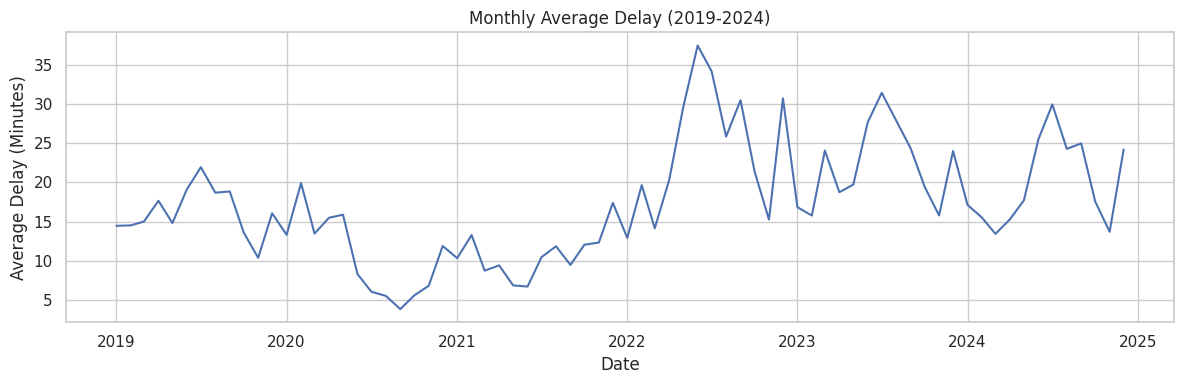

In [ ]:
# EDA – key visualizations (saved to outputs/figures)

# -----------------------
# EDA – key visualizations (saved to outputs/figures)
# -----------------------
monthly = flights.groupby('period_dt', dropna=True)['average_delay_mins'].mean().reset_index()

plt.figure(figsize=(12,4))
sns.lineplot(x='period_dt', y='average_delay_mins', data=monthly)
plt.title('Monthly Average Delay (2019-2024)')
plt.xlabel('Date')
plt.ylabel('Average Delay (Minutes)')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'monthly_average_delay.png'))
plt.show()

In [ ]:
# EDA – key visualizations (saved to outputs/figures)
# -----------------------

# Plot 1: Monthly Average Delay
monthly = flights.groupby('period_dt', dropna=True)['average_delay_mins'].mean().reset_index()
plt.figure(figsize=(12,4))
plt.plot(monthly['period_dt'], monthly['average_delay_mins'], marker='o')
plt.title('UK – Monthly Average Delay (mins)')
plt.xlabel('Month')
plt.ylabel('Average Delay (mins)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_monthly_avg_delay.png'), dpi=200)
plt.close()

# Plot 2: Top 15 Routes by Average Delay
route_delay = flights.groupby('route_key')['average_delay_mins'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
route_delay.sort_values().plot(kind='barh', color='#d62728')
plt.title('Top 15 Routes by Average Delay (mins)')
plt.xlabel('Average Delay (mins)')
plt.ylabel('Route')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_top_routes_delay.png'), dpi=200)
plt.close()

# Plot 3: Distribution of Average Delay
plt.figure(figsize=(8,5))
sns.histplot(flights['average_delay_mins'].dropna(), bins=50, kde=True, color='#1f77b4')
plt.title('Distribution of Average Delay (mins)')
plt.xlabel('Average Delay (mins)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_delay_distribution.png'), dpi=200)
plt.close()

In [ ]:
# Helper metrics
# -----------------------
def rmse(y_true, y_pred): return float(np.sqrt(mean_squared_error(y_true, y_pred)))
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred); eps = 1e-9
    return float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100)

In [ ]:
# Feature matrix
# -----------------------
feature_cols = [
    'reporting_airport','origin_destination_country','origin_destination',
    'airline_name','arr_dep','is_domestic','month','quarter','season',
    'delayed_rate_pct','ontime_core_pct','early_gt15_pct','residual_pct',
    'total_flights_index'
]
feature_cols = [c for c in feature_cols if c in flights.columns]

cat_cols = [c for c in feature_cols if flights[c].dtype == 'object']
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [ ]:
# Task A – Binary (LogReg, RF, XGB, CatBoost)
# -----------------------
results_taskA = []
X_train, y_train = train_df[feature_cols], train_df['y_taskA_binary']
X_val,   y_val   = val_df[feature_cols],   val_df['y_taskA_binary']
X_test,  y_test  = test_df[feature_cols],  test_df['y_taskA_binary']

In [ ]:
#df['y_taskA_binary']
X_val,   y_val   = val_df[feature_cols],   val_df['y_taskA_binary']
X_test,  y_test  = test_df[feature_cols],  test_df['y_taskA_binary']

In [ ]:
# Logistic Regression
logreg_clf = Pipeline(steps=[('prep', preprocess), ('clf', LogisticRegression(max_iter=1000))])
logreg_clf.fit(X_train, y_train)
for split_name, X_, y_ in [('val', X_val, y_val), ('test', X_test, y_test)]:
    pred = logreg_clf.predict(X_)
    results_taskA.append({'model':'LogisticRegression','split':split_name,
                          'accuracy':accuracy_score(y_, pred),
                          'f1_weighted':f1_score(y_, pred, average='weighted')})
joblib.dump(logreg_clf, os.path.join(MODEL_DIR, 'taskA_logreg.pkl'))

['outputs/models/taskA_logreg.pkl']

In [ ]:
# Random Forest
rf_clf = Pipeline(steps=[('prep', preprocess), ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))])
rf_clf.fit(X_train, y_train)
for split_name, X_, y_ in [('val', X_val, y_val), ('test', X_test, y_test)]:
    pred = rf_clf.predict(X_)
    results_taskA.append({'model':'RandomForest','split':split_name,
                          'accuracy':accuracy_score(y_, pred),
                          'f1_weighted':f1_score(y_, pred, average='weighted')})
joblib.dump(rf_clf, os.path.join(MODEL_DIR, 'taskA_randomforest.pkl'))

['outputs/models/taskA_randomforest.pkl']

In [ ]:
# XGBoost (optional)
if xgb is not None:
    xgb_clf = Pipeline(steps=[('prep', preprocess), ('clf', xgb.XGBClassifier(
        n_estimators=600, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
        random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss'
    ))])
    xgb_clf.fit(X_train, y_train)
    for split_name, X_, y_ in [('val', X_val, y_val), ('test', X_test, y_test)]:
        pred = xgb_clf.predict(X_)
        results_taskA.append({'model':'XGBoost','split':split_name,
                              'accuracy':accuracy_score(y_, pred),
                              'f1_weighted':f1_score(y_, pred, average='weighted')})
    joblib.dump(xgb_clf, os.path.join(MODEL_DIR, 'taskA_xgboost.pkl'))
else:
    with open(os.path.join(LOG_DIR, 'xgboost_unavailable.txt'), 'w') as f:
        f.write('xgboost not installed; Task A XGBoost skipped.')

In [ ]:
# Task B – Multi-class (LogReg, RF, XGB, CatBoost)
# -----------------------
results_taskB = []
X_train, y_train = train_df[feature_cols], train_df['y_taskB_multiclass']
X_val,   y_val   = val_df[feature_cols],   val_df['y_taskB_multiclass']
X_test,  y_test  = test_df[feature_cols],  test_df['y_taskB_multiclass']

In [ ]:
# Logistic Regression
logreg_clf_b = Pipeline(steps=[('prep', preprocess), ('clf', LogisticRegression(max_iter=1000))])
logreg_clf_b.fit(X_train, y_train)
for split_name, X_, y_ in [('val', X_val, y_val), ('test', X_test, y_test)]:
    pred = logreg_clf_b.predict(X_)
    results_taskB.append({'model':'LogisticRegression','split':split_name,
                           'accuracy':accuracy_score(y_, pred),
                           'f1_weighted':f1_score(y_, pred, average='weighted')})
joblib.dump(logreg_clf_b, os.path.join(MODEL_DIR, 'taskB_logreg.pkl'))

['outputs/models/taskB_logreg.pkl']

In [ ]:
# Random Forest
rf_clf_b = Pipeline(steps=[('prep', preprocess), ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))])
rf_clf_b.fit(X_train, y_train)
for split_name, X_, y_ in [('val', X_val, y_val), ('test', X_test, y_test)]:
    pred = rf_clf_b.predict(X_)
    results_taskB.append({'model':'RandomForest','split':split_name,
                           'accuracy':accuracy_score(y_, pred),
                           'f1_weighted':f1_score(y_, pred, average='weighted')})
joblib.dump(rf_clf_b, os.path.join(MODEL_DIR, 'taskB_randomforest.pkl'))

In [ ]:
# XGBoost (optional)
if xgb is not None:
    xgb_clf_b = Pipeline(steps=[('prep', preprocess), ('clf', xgb.XGBClassifier(
        n_estimators=600, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
        random_state=42, n_jobs=-1, objective='multi:softmax', num_class=3, eval_metric='mlogloss'
    ))])
    xgb_clf_b.fit(X_train, y_train)
    for split_name, X_, y_ in [('val', X_val, y_val), ('test', X_test, y_test)]:
        pred = xgb_clf_b.predict(X_)
        results_taskB.append({'model':'XGBoost','split':split_name,
                              'accuracy':accuracy_score(y_, pred),
                              'f1_weighted':f1_score(y_, pred, average='weighted')})
    joblib.dump(xgb_clf_b, os.path.join(MODEL_DIR, 'taskB_xgboost.pkl'))
else:
    with open(os.path.join(LOG_DIR, 'xgboost_unavailable_b.txt'), 'w') as f:
        f.write('xgboost not installed; Task B XGBoost skipped.')

In [ ]:
# CatBoost (optional)
if CatBoostClassifier is not None:
    cat_clf_b = Pipeline(steps=[('prep', preprocess), ('clf', CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=0,
        early_stopping_rounds=50, loss_function='MultiClass'
    ))])
    cat_clf_b.fit(X_train, y_train)
    for split_name, X_, y_ in [('val', X_val, y_val), ('test', X_test, y_test)]:
        pred = cat_clf_b.predict(X_)
        results_taskB.append({'model':'CatBoost','split':split_name,
                              'accuracy':accuracy_score(y_, pred),
                              'f1_weighted':f1_score(y_, pred, average='weighted')})
    joblib.dump(cat_clf_b, os.path.join(MODEL_DIR, 'taskB_catboost.pkl'))
else:
    with open(os.path.join(LOG_DIR, 'catboost_unavailable_b.txt'), 'w') as f:
        f.write('CatBoost not installed; Task B CatBoost skipped.')